In [2]:
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd
from pathlib import Path

labels = [
    "kv_cache_100tok",
    "kv_cache_300tok",
    "kv_cache_500tok",
    "kv_cache_750tok",
    "kv_cache_1000tok",
]

data = {}
for label in labels:
    path = Path(f"../results/metrics/{label}.json")
    with open(path) as f:
        data[label] = json.load(f)

print("Loaded JSON files:")
for label, d in data.items():
    itl = np.array(d["itl_per_position"])
    print(f"  {label}: {len(itl)} positions, "
          f"mean={itl.mean():.1f}ms, "
          f"max={itl.max():.1f}ms at pos {itl.argmax()}, "
          f"memory={d['peak_memory_mb']:.0f}MB")

Loaded JSON files:
  kv_cache_100tok: 300 positions, mean=34.3ms, max=69.1ms at pos 144, memory=2113MB
  kv_cache_300tok: 900 positions, mean=33.1ms, max=70.2ms at pos 595, memory=2122MB
  kv_cache_500tok: 1500 positions, mean=32.7ms, max=65.5ms at pos 842, memory=2132MB
  kv_cache_750tok: 2250 positions, mean=32.9ms, max=67.0ms at pos 54, memory=2143MB
  kv_cache_1000tok: 3000 positions, mean=32.9ms, max=63.7ms at pos 1474, memory=2155MB


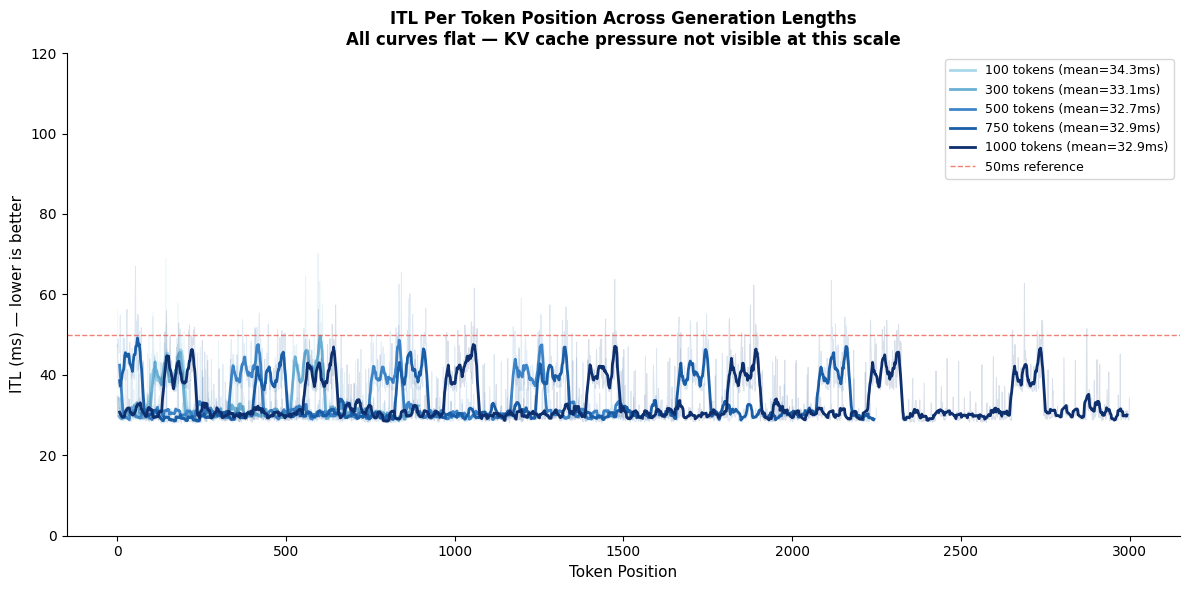

In [3]:
fig, ax = plt.subplots(figsize=(12, 6))

colors = ["#a8d8ea", "#6ab0d4", "#3d85c8", "#1a5ea8", "#0d2f6e"]
window = 15

for idx, label in enumerate(labels):
    itl      = np.array(data[label]["itl_per_position"])
    positions = np.arange(len(itl))
    n_tokens  = data[label]["max_new_tokens"]

    ax.plot(positions, itl,
            color=colors[idx], alpha=0.15, linewidth=0.7)

    smooth = np.convolve(itl, np.ones(window)/window, mode='valid')
    ax.plot(np.arange(len(smooth)) + window//2, smooth,
            color=colors[idx], linewidth=2,
            label=f"{n_tokens} tokens (mean={itl.mean():.1f}ms)")

ax.axhline(y=50, color="#e74c3c", linestyle="--",
           linewidth=1, alpha=0.7, label="50ms reference")

ax.set_xlabel("Token Position", fontsize=11)
ax.set_ylabel("ITL (ms) — lower is better", fontsize=11)
ax.set_title("ITL Per Token Position Across Generation Lengths\n"
             "All curves flat — KV cache pressure not visible at this scale",
             fontsize=12, fontweight="bold")
ax.legend(fontsize=9)
ax.set_ylim(0, 120)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
Path("../results/figures/kv_cache").mkdir(parents=True, exist_ok=True)
plt.savefig("../results/figures/kv_cache/itl_per_position_all_lengths.png",
            dpi=150, bbox_inches="tight")
plt.show()

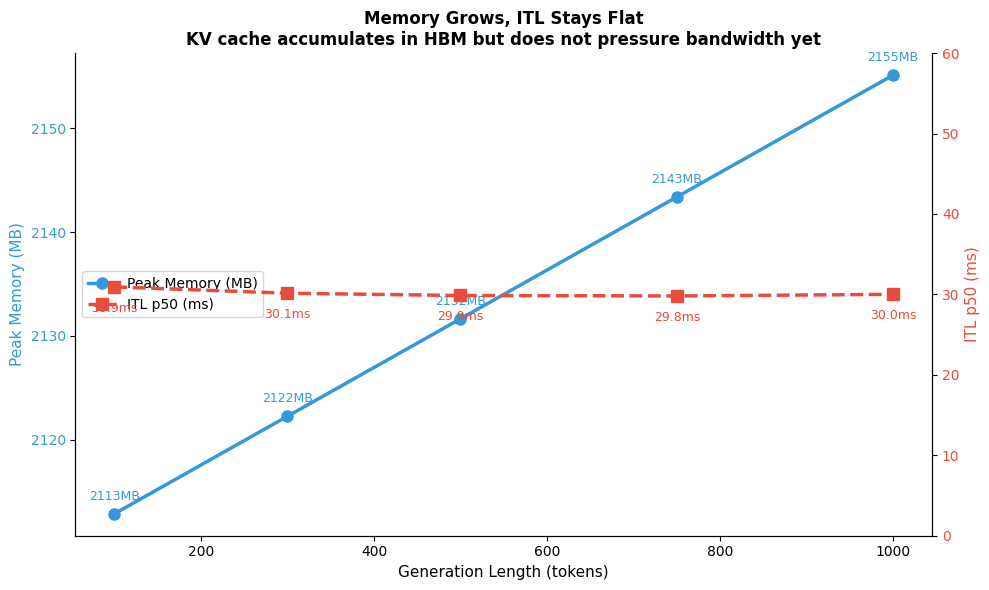

Memory growth:
   100 tok: 2113MB total, ~18MB theoretical KV cache
   300 tok: 2122MB total, ~54MB theoretical KV cache
   500 tok: 2132MB total, ~90MB theoretical KV cache
   750 tok: 2143MB total, ~135MB theoretical KV cache
  1000 tok: 2155MB total, ~180MB theoretical KV cache


In [5]:
fig, ax1 = plt.subplots(figsize=(10, 6))

generation_lengths = [data[l]["max_new_tokens"] for l in labels]
memory_vals        = [data[l]["peak_memory_mb"] for l in labels]
itl_p50_vals       = [data[l]["itl_p50_ms"] for l in labels]

color_mem = "#3498db"
ax1.set_xlabel("Generation Length (tokens)", fontsize=11)
ax1.set_ylabel("Peak Memory (MB)", color=color_mem, fontsize=11)
ax1.plot(generation_lengths, memory_vals,
         color=color_mem, marker="o", linewidth=2.5,
         markersize=8, label="Peak Memory (MB)")
ax1.tick_params(axis='y', labelcolor=color_mem)

for x, y in zip(generation_lengths, memory_vals):
    ax1.annotate(f"{y:.0f}MB",
                 (x, y), textcoords="offset points",
                 xytext=(0, 10), ha="center",
                 fontsize=9, color=color_mem)

ax2 = ax1.twinx()
color_itl = "#e74c3c"
ax2.set_ylabel("ITL p50 (ms)", color=color_itl, fontsize=11)
ax2.plot(generation_lengths, itl_p50_vals,
         color=color_itl, marker="s", linewidth=2.5,
         markersize=8, linestyle="--", label="ITL p50 (ms)")
ax2.tick_params(axis='y', labelcolor=color_itl)
ax2.set_ylim(0, 60)

for x, y in zip(generation_lengths, itl_p50_vals):
    ax2.annotate(f"{y:.1f}ms",
                 (x, y), textcoords="offset points",
                 xytext=(0, -18), ha="center",
                 fontsize=9, color=color_itl)

ax1.set_title("Memory Grows, ITL Stays Flat\n"
              "KV cache accumulates in HBM but does not pressure bandwidth yet",
              fontsize=12, fontweight="bold")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2,
           loc="center left", fontsize=10)

ax1.spines["top"].set_visible(False)
ax2.spines["top"].set_visible(False)

plt.tight_layout()
plt.savefig("../results/figures/kv_cache/memory_vs_itl.png",
            dpi=150, bbox_inches="tight")
plt.show()

# Print delta
print("Memory growth:")
for l in labels:
    n   = data[l]["max_new_tokens"]
    mem = data[l]["peak_memory_mb"]
    theoretical_cache = n * 0.18
    print(f"  {n:4d} tok: {mem:.0f}MB total, "
          f"~{theoretical_cache:.0f}MB theoretical KV cache")

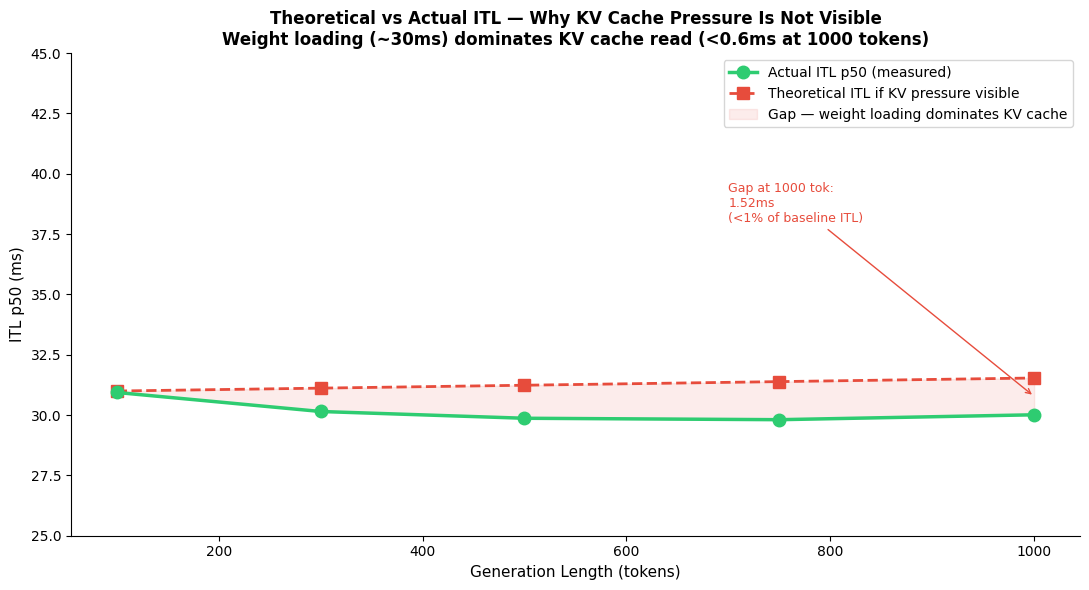


Theoretical KV cache contribution to ITL:
   100 tok: KV adds 0.060ms (0.19% of actual ITL 30.9ms)
   300 tok: KV adds 0.180ms (0.60% of actual ITL 30.1ms)
   500 tok: KV adds 0.300ms (1.00% of actual ITL 29.9ms)
   750 tok: KV adds 0.450ms (1.51% of actual ITL 29.8ms)
  1000 tok: KV adds 0.600ms (2.00% of actual ITL 30.0ms)


In [6]:
fig, ax = plt.subplots(figsize=(11, 6))

generation_lengths = [data[l]["max_new_tokens"] for l in labels]
itl_actual         = [data[l]["itl_p50_ms"] for l in labels]

baseline_itl = itl_actual[0]  

theoretical_itl = [
    baseline_itl + (n * 0.18 / 300_000) * 1000
    for n in generation_lengths
]

# Actual
ax.plot(generation_lengths, itl_actual,
        color="#2ecc71", marker="o", linewidth=2.5,
        markersize=9, label="Actual ITL p50 (measured)", zorder=5)

# Theoretical
ax.plot(generation_lengths, theoretical_itl,
        color="#e74c3c", marker="s", linewidth=2,
        markersize=8, linestyle="--",
        label="Theoretical ITL if KV pressure visible", zorder=4)

# Fill gap
ax.fill_between(generation_lengths, itl_actual, theoretical_itl,
                alpha=0.1, color="#e74c3c",
                label="Gap — weight loading dominates KV cache")

# Annotate gap at 1000 token
gap_at_1000 = theoretical_itl[-1] - itl_actual[-1]
ax.annotate(f"Gap at 1000 tok:\n{gap_at_1000:.2f}ms\n(<1% of baseline ITL)",
            xy=(1000, (theoretical_itl[-1] + itl_actual[-1]) / 2),
            xytext=(700, 38),
            fontsize=9, color="#e74c3c",
            arrowprops=dict(arrowstyle="->", color="#e74c3c"))

ax.set_xlabel("Generation Length (tokens)", fontsize=11)
ax.set_ylabel("ITL p50 (ms)", fontsize=11)
ax.set_title("Theoretical vs Actual ITL — Why KV Cache Pressure Is Not Visible\n"
             "Weight loading (~30ms) dominates KV cache read (<0.6ms at 1000 tokens)",
             fontsize=12, fontweight="bold")
ax.set_ylim(25, 45)
ax.legend(fontsize=10)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig("../results/figures/kv_cache/theoretical_vs_actual.png",
            dpi=150, bbox_inches="tight")
plt.show()

print("\nTheoretical KV cache contribution to ITL:")
for n, th, ac in zip(generation_lengths, theoretical_itl, itl_actual):
    contribution = th - baseline_itl
    pct          = (contribution / ac) * 100
    print(f"  {n:4d} tok: KV adds {contribution:.3f}ms "
          f"({pct:.2f}% of actual ITL {ac:.1f}ms)")

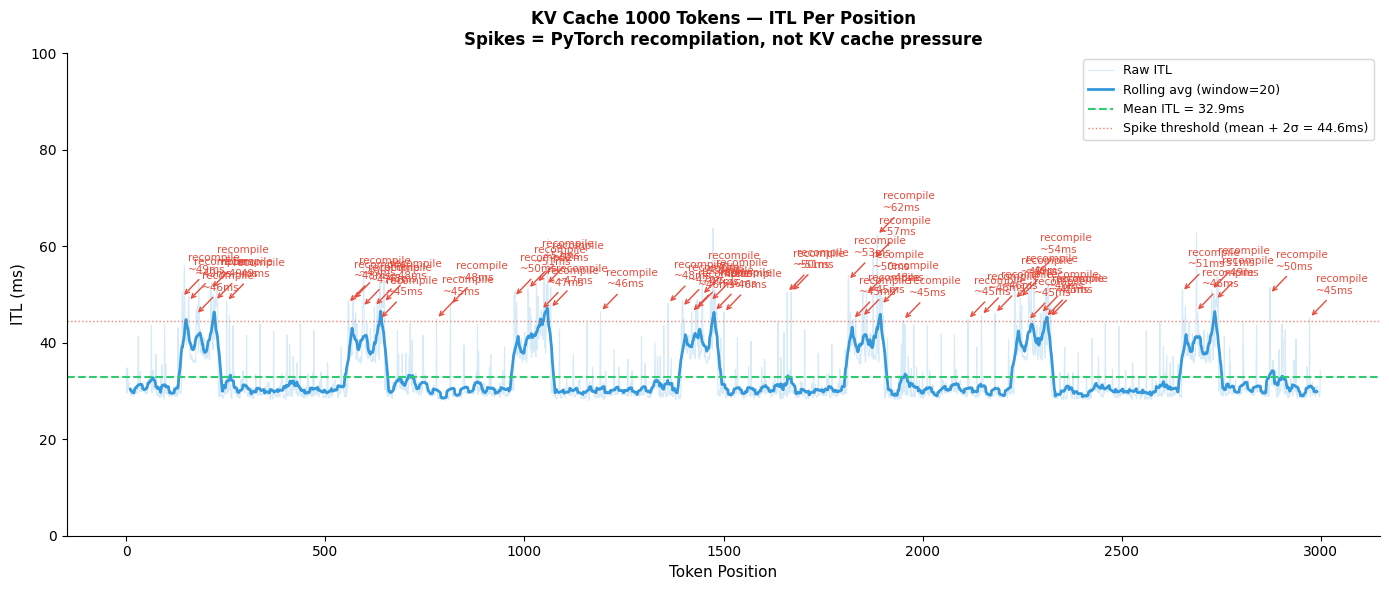


Spike analysis for kv_cache_1000tok:
  Mean ITL:       32.9ms
  Std ITL:        5.8ms
  Spike threshold: 44.6ms
  Spike positions: [140, 141, 145, 146, 147, 156, 157, 175, 176, 177]...
  Total spikes:    207
  Spike pattern:   every ~24 tokens


In [8]:
fig, ax = plt.subplots(figsize=(14, 6))

itl_1000  = np.array(data["kv_cache_1000tok"]["itl_per_position"])
positions = np.arange(len(itl_1000))
window    = 20

smooth = np.convolve(itl_1000, np.ones(window)/window, mode='valid')

ax.plot(positions, itl_1000,
        color="#3498db", alpha=0.2, linewidth=0.8, label="Raw ITL")
ax.plot(np.arange(len(smooth)) + window//2, smooth,
        color="#3498db", linewidth=2,
        label=f"Rolling avg (window={window})")

mean_itl = itl_1000.mean()
std_itl  = itl_1000.std()
threshold = mean_itl + 2 * std_itl
spike_positions = np.where(itl_1000 > threshold)[0]

annotated = []
for pos in spike_positions:
    if not any(abs(pos - a) < 10 for a in annotated):
        ax.annotate(f"recompile\n~{itl_1000[pos]:.0f}ms",
                    xy=(pos, itl_1000[pos]),
                    xytext=(pos + 15, itl_1000[pos] + 5),
                    fontsize=7.5, color="#e74c3c",
                    arrowprops=dict(arrowstyle="->",
                                    color="#e74c3c", lw=1))
        annotated.append(pos)

ax.axhline(y=mean_itl, color="#2ecc71", linestyle="--",
           linewidth=1.5, label=f"Mean ITL = {mean_itl:.1f}ms")
ax.axhline(y=threshold, color="#e74c3c", linestyle=":",
           linewidth=1, alpha=0.7,
           label=f"Spike threshold (mean + 2σ = {threshold:.1f}ms)")

ax.set_xlabel("Token Position", fontsize=11)
ax.set_ylabel("ITL (ms)", fontsize=11)
ax.set_title("KV Cache 1000 Tokens — ITL Per Position\n"
             "Spikes = PyTorch recompilation, not KV cache pressure",
             fontsize=12, fontweight="bold")
ax.legend(fontsize=9)
ax.set_ylim(0, 100)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig("../results/figures/kv_cache/recompilation_vs_kv_pressure.png",
            dpi=150, bbox_inches="tight")
plt.show()

print(f"\nSpike analysis for kv_cache_1000tok:")
print(f"  Mean ITL:       {mean_itl:.1f}ms")
print(f"  Std ITL:        {std_itl:.1f}ms")
print(f"  Spike threshold: {threshold:.1f}ms")
print(f"  Spike positions: {spike_positions.tolist()[:10]}...")
print(f"  Total spikes:    {len(spike_positions)}")
print(f"  Spike pattern:   every ~{np.diff(annotated[:4]).mean():.0f} tokens")